## 调用一些基本的库，必须是pyth12 环境下

In [1]:
%load_ext autoreload
%autoreload 2

import os

import matplotlib.patches as patches
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

## 导入 数据分析包 process， 以及 run_id, 数据路径等参数信息

In [3]:
from waveform_analysis.core.context import Context

from waveform_analysis.core.processing.dtypes import create_record_dtype

run_id = "00179"
ctx = Context(storage_dir="/mnt/data/TPC/run6_Xe/")

from waveform_analysis.core.plugins.plugin_sets import (
    plugins_basic_features, 
    plugins_events,
    plugins_io,
    plugins_peaks,
    plugins_tabular,
    plugins_waveform,
)

ctx.register(*plugins_io())
ctx.register(*plugins_waveform())
ctx.register(*plugins_basic_features())
ctx.register(*plugins_peaks())
ctx.register(*plugins_events())
ctx.register(*plugins_tabular())


In [4]:
# ctx.show_config()

In [5]:
ctx.key_for(run_id, 'records')

'00179-records-c155b8eb'

## 定义 data process 配置参数等

In [7]:
ctx.set_config({
    "data_root": "/mnt/data/TPC/run6_Xe/",
    "run_config_path": "/mnt/data/TPC/run6_Xe/run_config.json",
    # "custom_config_json_path": "run5_process.json",
    "daq_adapter": "v1725",  # 文件名包含 @VX2730，需要适配器
    "show_progress": True,
    "use_filtered": False,
    "wave_source": "records",
})
# ctx.get_plugin("st_waveforms").save_when = "always"
# ctx.set_config({"records_part_size": 25000000, "channel_workers": 1, "n_jobs": 64}, "records")
ctx.set_config(
    {
        "channel_workers": 14,
        "n_jobs": 14,
        "v1725_part_size": 20_000,
        "use_process_pool": True,
        "channel_executor": "process",
        "keep_on_disk": True,
    },
    plugin_name="records",
)
ctx.set_config({"area_range": (0, None), "height_range": (0, None)}, "basic_features")
ctx.set_config(
    {
        "asymmetry_cut_min": 0.7,
        "asymmetry_chunk_size": 200_000,
        "asymmetry_num_threads": 128,
    },
    "records_asymmetry_mask",
)
ctx.set_config(
    config={"threshold": 30, "asymmetry_cut_enabled": True, "right_extension": 5}, plugin_name="hit_threshold"
)
ctx.set_config({"merge_gap_ns": 400, "max_total_width_ns": 40000}, "hit_merged")
ctx.set_config(
    {
        "time_window_ns": 200.0,
        "max_total_width_ns": 50000.0,
        "dt": 4,
    },
    "peaklets",
)

In [8]:
print(f"/mnt/data/TPC/run6_Xe/{run_id}/runinfo.json")

/mnt/data/TPC/run6_Xe/00179/runinfo.json


In [9]:
# ctx.plot_lineage('basic_features',verbose=2)

In [10]:
# ctx.plot_lineage( "hit_merged")

In [10]:
ctx.get_data(run_id, "hit_threshold")

[cache] Loaded 'hit_threshold' from disk (run_id: 00179)


memmap([( 93,  46.,  94.,  90.,  96., 6., 4, 4., 0.,       248164000, 0, 11,       9,  90,  96,       2340,       2346),
        ( 93, 111., 176.,  91.,  97., 6., 4, 0., 4.,       248164000, 0, 12,      10,  91,  97,       2591,       2597),
        (204,  11.,  12., 202., 207., 5., 4, 0., 0.,      1248576000, 1, 12,      17, 202, 207,       4452,       4457),
        ...,
        ( 95,  48.,  99.,  93.,  99., 6., 4, 0., 4., 299994671548000, 0, 14, 4199949,  93,  99, 1049987343, 1049987349),
        ( 96,  47.,  89.,  94., 101., 7., 4, 0., 8., 299995671552000, 0, 14, 4199970,  94, 101, 1049992594, 1049992601),
        ( 95,  77., 153.,  93., 100., 7., 4, 0., 8., 299995671548000, 0, 15, 4199971,  93, 100, 1049992843, 1049992850)],
       shape=(857157,), dtype=[('position', '<i8'), ('height', '<f4'), ('integral', '<f4'), ('edge_start', '<f4'), ('edge_end', '<f4'), ('width', '<f4'), ('dt', '<i4'), ('rise_time', '<f4'), ('fall_time', '<f4'), ('timestamp', '<i8'), ('board', '<i2'), ('chann

In [11]:
ctx.get_data(run_id, "raw_files")

[+] Running plugin: raw_files (run_id: 00179)


[['/mnt/data/TPC/run6_Xe/00179/RAW/run6_Xe_20260605_110413_00179_raw_b0_seg0.bin',
  '/mnt/data/TPC/run6_Xe/00179/RAW/run6_Xe_20260605_110413_00179_raw_b0_seg1.bin'],
 ['/mnt/data/TPC/run6_Xe/00179/RAW/run6_Xe_20260605_110413_00179_raw_b1_seg0.bin',
  '/mnt/data/TPC/run6_Xe/00179/RAW/run6_Xe_20260605_110413_00179_raw_b1_seg1.bin']]

In [11]:
ctx.set_config({"records_part_size":25000000,
             "channel_workers":10,
             "n_jobs":64},"records")
# ctx.show_config("records")

## 读取原始波形数据

In [12]:
from waveform_analysis.core import records_view

rv = records_view(ctx, run_id)

records = rv.records      # 你看到的 memmap
wave_pool = rv.wave_pool  # 真正的连续波形池

def get_wave(i: int):
    off = int(records["wave_offset"][i])
    n = int(records["event_length"][i])
    w = wave_pool[off:off+n]          # 1D view (uint16)    
    return w.view("i2")

2026-07-12 19:24:05,709 - Context - INFO - Detected run_config change for run '00179' (sha1:37683127e8081599676dd05dc79b42f07acbd562 -> missing); invalidating related caches.


[+] Running plugin: raw_files (run_id: 00179)
[+] Running plugin: records (run_id: 00179)


Building V1725 records:  75%|███████▌  | 3/4 [00:26<00:09,  9.77s/it]

[Records 合并入口] 分片数=422, batch_size=50, n_workers=64, executor=process
[Records 合并] records-only batch merge, 模式=并行, executor=process, workers=64, 批次数=9, 分片数=422


[Records 合并] records-only final sort merge, 分片数=9
[Records 合并] wave_pool concat, 分片数=422, samples=1049993000


[+] Running plugin: wave_pool (run_id: 00179)


In [13]:
print(records.dtype.names)

('timestamp', 'pid', 'board', 'channel', 'baseline', 'baseline_upstream', 'polarity', 'record_id', 'dt', 'trigger_type', 'flags', 'wave_offset', 'event_length', 'time')


## 将数据类型 records存为 DataFrame 格式

In [14]:
pd.DataFrame(ctx.get_data(run_id, "records")[:3])

,timestamp,pid,board,channel,baseline,baseline_upstream,polarity,record_id,dt,trigger_type,flags,wave_offset,event_length,time
0,247776000,0,1,9,9602.0,NaN,unknown,0,4,0,0,524996500,250,247776
1,247776000,0,1,10,9537.0,NaN,unknown,1,4,0,0,524996750,250,247776
2,247776000,0,1,11,9553.0,NaN,unknown,2,4,0,0,524997000,250,247776


In [476]:
# ctx.get_data(run_id, "records")["channel"]

In [13]:
# import matplotlib.pyplot as plt
# plt.hist(ctx.get_data(run_id, "records")["baseline"],bins=np.linspace(0, 16000, 200))
# plt.yscale("log")
# plt.show()


In [35]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 获取全量记录数据
# records_data = ctx.get_data(run_id, "records")

# # 指定要筛选的通道（例如 board=0, channel=12）
# board_id = 0
# channel_id = 12

# # 布尔索引筛选
# mask = (records_data["board"] == board_id) & (records_data["channel"] == channel_id)
# baseline_ch = records_data[mask]["baseline"]

# # 绘制直方图
# plt.figure(figsize=(8, 5))
# plt.hist(baseline_ch, bins=np.linspace(14700, 15200, 100), alpha=0.7, edgecolor='black')
# plt.yscale("log")
# plt.xlabel("Baseline (ADC units)")
# plt.ylabel("Count (log scale)")
# plt.title(f"Baseline distribution | Board {board_id}, Channel {channel_id}")
# plt.grid(True, alpha=0.3)
# plt.show()

In [34]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import LogNorm

# df = ctx.get_data(run_id, "basic_features")

# # 2行4列
# fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)
# # 如果希望4行2列则改为 (4,2)，但用户说4列2行，即2行4列，下面按2行4列写

# x_bins = np.logspace(1, 4, 200)
# y_bins = np.logspace(1, 3, 200)
# norm = LogNorm(vmin=1, vmax=10000)

# last_im = None

# board = 0
# channels = list(range(9, 16))  # 9,10,11,12,13,14,15

# for idx, ch in enumerate(channels):
#     # 计算子图位置：2行4列，按行优先（即第一行从左到右，第二行从左到右）
#     row = idx // 4
#     col = idx % 4
#     ax = axes[row, col]

#     df_ch = df[(df["channel"] == ch) & (df["board"] == board)]
#     h = ax.hist2d(
#         df_ch["area"],
#         df_ch["height"],
#         bins=(x_bins, y_bins),
#         norm=norm,
#         cmin=1,
#     )
#     last_im = h[3]
#     ax.set_xlabel("area")
#     ax.set_ylabel("height")
#     ax.set_title(f"board {board} channel {ch}")
#     ax.set_xscale("log")
#     ax.set_yscale("log")

# # 如果有剩余的子图（第8个位置），可以隐藏或者不处理
# # 但为了美观，可以将其隐藏或留空
# # 因为只有7个通道，最后一个子图（idx=7）不存在，axes[1,3] 是空着的
# # 可以设置该子图为不可见
# if idx < (2*4 -1):  # 如果最后一个子图没有被填充
#     for i in range(idx+1, 2*4):
#         row = i // 4
#         col = i % 4
#         axes[row, col].axis('off')

# fig.colorbar(last_im, ax=axes.ravel().tolist(), label="counts", shrink=0.9)
# fig.tight_layout()
# plt.show()

### 检查每个通道波形数据

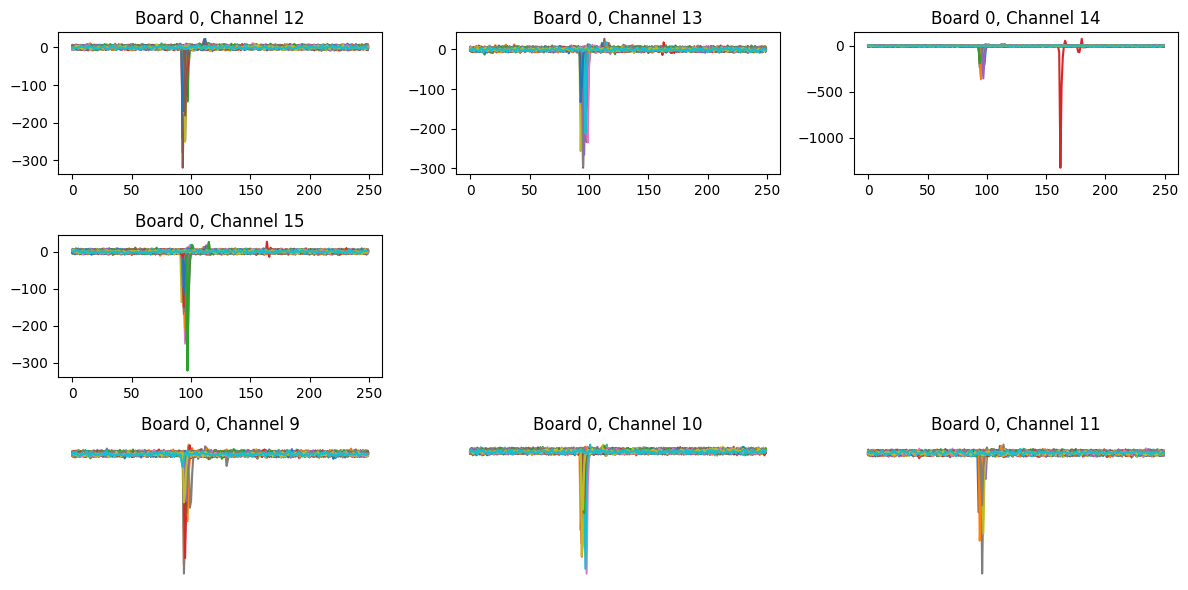

In [294]:
import matplotlib.pyplot as plt
import numpy as np

board = 0
fig, axes = plt.subplots(3, 3, figsize=(12, 6))

for channel in range(9, 16):
    num = channel - 12          # board=0 时的简化索引
    ax = axes[num // 3][num % 3]
    
    select_runid = records[(records['channel'] == channel) & (records['board'] == board)]["record_id"]
    ax.plot(rv.signals(select_runid[:100]).T)
    ax.set_title(f"Board {board}, Channel {channel}")

# 隐藏多余的子图（3x3 共9格，只用了4个）
for idx in range(4, 9):
    axes[idx // 3][idx % 3].axis('off')

plt.tight_layout()
plt.show()

## 打印筛选波形主要分布的时间窗口

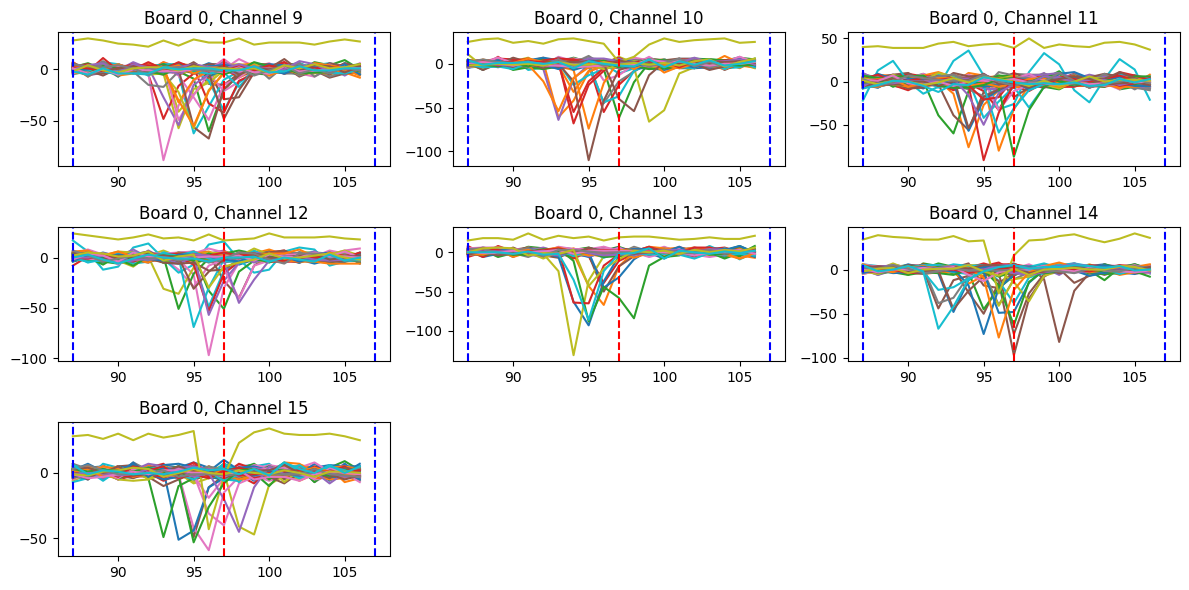

In [429]:
import matplotlib.pyplot as plt
import numpy as np

board = 0
fig, axes = plt.subplots(3, 3, figsize=(12, 6))

channels = list(range(9, 16))

for idx, channel in enumerate(channels):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    select_runid = records[(records['channel'] == channel) & (records['board'] == board)]["record_id"][:100]
    signals = rv.signals(select_runid)

    center = 97
    half = 10
    start = max(0, center - half)
    end = min(signals.shape[1], center + half)

    signals_sliced = signals[:, start:end]
    x_original = np.arange(start, end)          # 原始坐标

    ax.plot(x_original, signals_sliced.T)
    ax.set_title(f"Board {board}, Channel {channel}")
    ax.axvline(center, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(97-10, color='blue', linestyle='--', linewidth=1.5)
    ax.axvline(97+10, color='blue', linestyle='--', linewidth=1.5)

# 隐藏多余子图
for idx in range(len(channels), 9):
    axes[idx // 3][idx % 3].axis('off')

plt.tight_layout()
plt.show()

### 分析波形极限抖动情况，并打印直方图

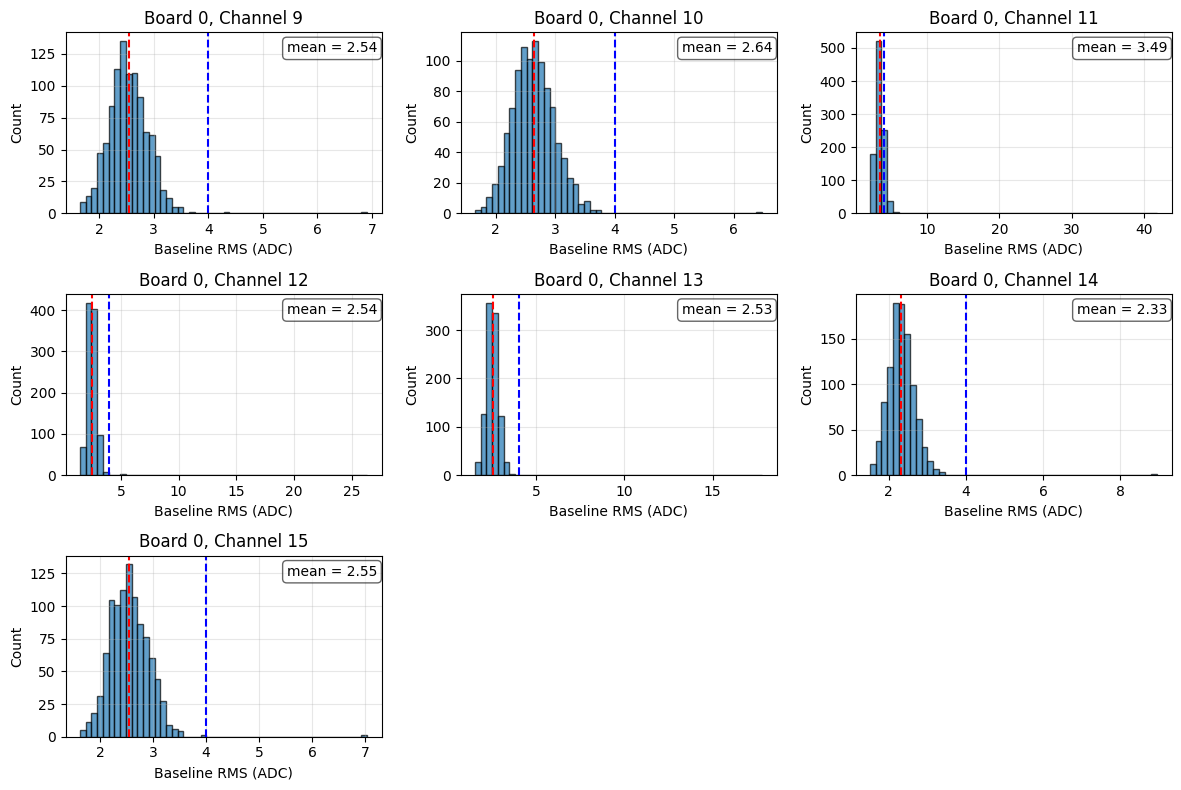

In [414]:
import matplotlib.pyplot as plt
import numpy as np

# 固定参数
board = 0
channels = list(range(9, 16))   # board 0 的通道 9~15
n_waveforms = 1000              # 每个通道使用的波形数量
n_pre_samples = 30              # 计算 RMS 所用的起始点数

# 存储每个通道的 RMS 列表
rms_per_channel = {ch: [] for ch in channels}

for ch in channels:
    select_runid = records[(records['channel'] == ch) & (records['board'] == board)]["record_id"][:n_waveforms]
    signals = rv.signals(select_runid)
    
    for i in range(signals.shape[0]):
        segment = signals[i, :n_pre_samples]   # 前30个点
        rms_val = np.std(segment)             # 标准差作为 RMS
        rms_per_channel[ch].append(rms_val)

# 绘图：3x3 子图，只使用前 7 个，隐藏后 2 个
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, ch in enumerate(channels):
    ax = axes[idx]
    rms_vals = rms_per_channel[ch]
    mean_rms = np.mean(rms_vals)          # 计算均值（中心值）
    
    # 绘制直方图
    ax.hist(rms_vals, bins=50, alpha=0.7, edgecolor='black', label='RMS distribution')
    # 添加均值垂直线
    ax.axvline(mean_rms, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_rms:.2f}')
    ax.axvline(4, color='blue', linestyle='--', linewidth=1.5)
    
    ax.set_title(f"Board 0, Channel {ch}")
    ax.set_xlabel("Baseline RMS (ADC)")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    # 可选择使用对数纵轴（若分布范围宽）
    # ax.set_yscale('log')
    
    # 在右上角显示均值文本（不依赖图例）
    ax.text(0.7, 0.95, f'mean = {mean_rms:.2f}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
    # 可选：添加图例（如果希望同时显示线和标签）
    # ax.legend(loc='upper left')

# 隐藏多余子图
for idx in range(len(channels), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 计算、分析波形数据的非对称性，用于噪声排除

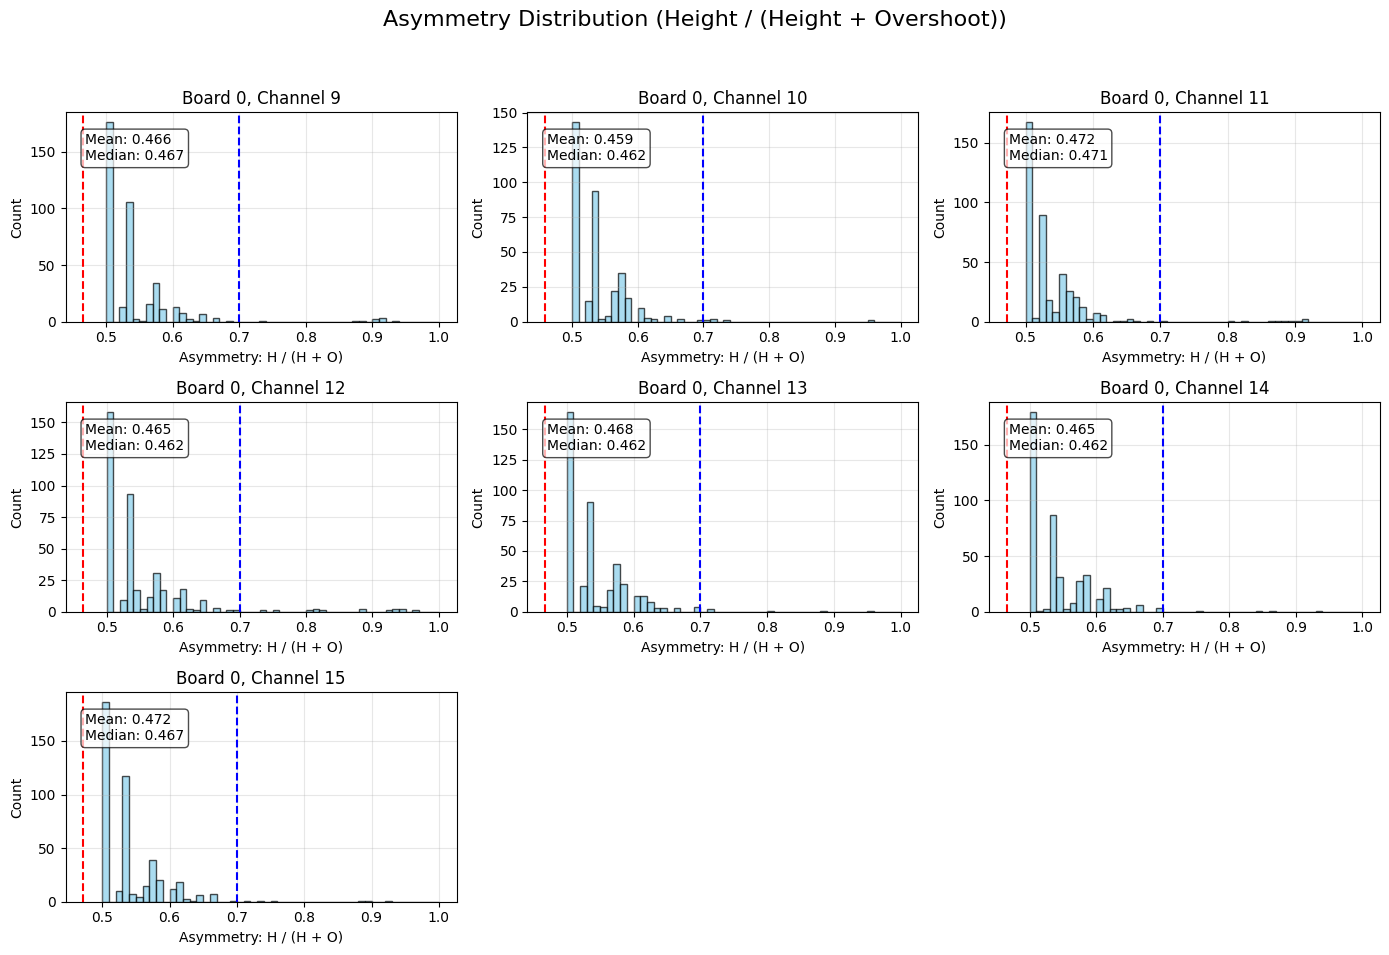

In [217]:
import matplotlib.pyplot as plt
import numpy as np

# 固定参数
board = 0
channels = list(range(9, 16))   # board 0 的通道 9~15
n_waveforms = 1000              # 每个通道使用的波形数量

# 存储每个通道的 Asymmetry 列表
asym_per_channel = {ch: [] for ch in channels}

for ch in channels:
    # 1. 获取 record_id
    select_runid = records[(records['channel'] == ch) & (records['board'] == board)]["record_id"][:n_waveforms]
    
    # 2. 获取波形数据 (假设 rv.signals 已经做了基线扣除，基线在 0 附近)
    # 如果 rv.signals 没有扣基线，请确保使用带有 baseline_correct=True 的方法
    signals = rv.signals(select_runid)
    
    for i in range(signals.shape[0]):
        wave = signals[i]
        
        # --- 计算 Asymmetry ---
        # 假设信号是负脉冲：
        # Height 是向下的峰（最小值），Overshoot 是向上的回弹（最大值）
        height = abs(np.min(wave))
        overshoot = np.max(wave)
        
        # 防止分母为 0 的简单处理
        if (height + overshoot) > 0:
            asym = height / (height + overshoot)
            asym_per_channel[ch].append(asym)
        else:
            asym_per_channel[ch].append(np.nan)

# 绘图：3x3 子图
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, ch in enumerate(channels):
    ax = axes[idx]
    # 过滤掉可能的 nan 值
    data = [x for x in asym_per_channel[ch] if not np.isnan(x)]
    
    if len(data) > 0:
        mean_asym = np.mean(data)
        median_asym = np.median(data)
        
        # 绘制直方图 (Asymmetry 范围通常在 0 到 1 之间)
        ax.hist(data, bins=50, range=(0.5, 1.0), color='skyblue', alpha=0.7, edgecolor='black')
        
        # 添加均值垂直线
        ax.axvline(mean_asym, color='red', linestyle='--', linewidth=1.5)
        ax.axvline(0.7, color='blue', linestyle='--', linewidth=1.5)
        # 标注文本
        ax.text(0.05, 0.9, f'Mean: {mean_asym:.3f}\nMedian: {median_asym:.3f}', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    ax.set_title(f"Board 0, Channel {ch}")
    ax.set_xlabel("Asymmetry: H / (H + O)")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

# 隐藏多余子图
for idx in range(len(channels), len(axes)):
    axes[idx].axis('off')

plt.suptitle("Asymmetry Distribution (Height / (Height + Overshoot))", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 再97sample前后各延申10个点，积分面积，遍历所有波形，并按通道存到字典里

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 可选：应用全局样式（取消注释以启用）
# plt.style.use('seaborn-v0_8-darkgrid')

# ========== 参数设置 ==========
pe_fact  = (2./16384)*4.e-9/(50*1.6e-19)/1.e6  ## to PE

board = 0
channels = list(range(9, 16))
n_waveforms = 300000
n_baseline_points = 30
center_idx = 97 
win_start = center_idx - 10
win_end = center_idx + 10
# # 是否翻转面积为正值（True=取绝对值，或者可以设置为 'neg_to_pos' 直接取反）
# FLIP_TO_POSITIVE = True
# FLIP_METHOD = 'abs'   # 可选 'abs' 或 'negate'

# 存储数据
integral_per_channel = {ch: [] for ch in channels}

# ========== 数据处理（带符号翻转） ==========
for ch in channels:
    select_runid = records[(records['channel'] == ch) & (records['board'] == board)]["record_id"][:n_waveforms]
    signals = rv.signals(select_runid)
    
    for i in range(signals.shape[0]):
        segment = signals[i, :n_baseline_points]   # 前30个点
        rms_val = np.std(segment) 
        if rms_val > 4:
            continue        
        baseline_val = np.mean(signals[i, :n_baseline_points])
        win_seg = signals[i, win_start:win_end]
        raw_area = -np.sum(win_seg - baseline_val)
        area_pe = raw_area*pe_fact               
        integral_per_channel[ch].append(area_pe)


### 打印SPE gain 分布特征

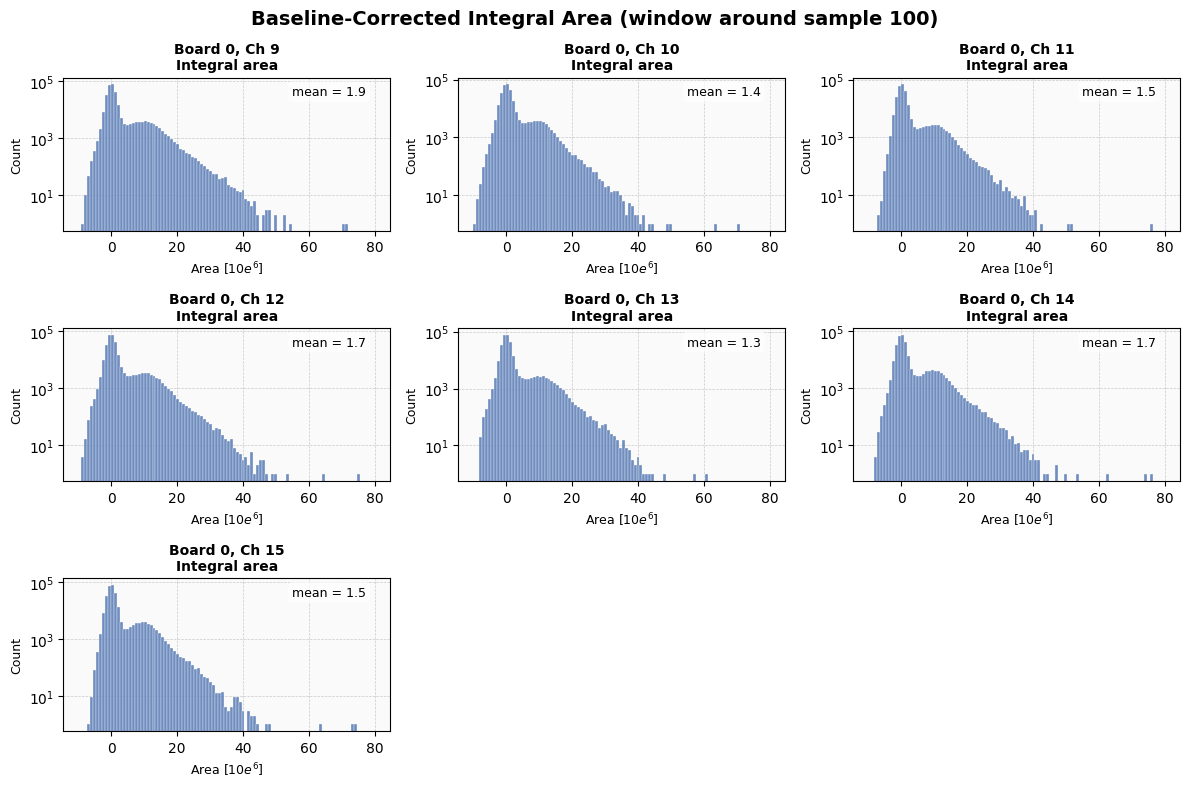

In [17]:

# ========== 图2：美化后的直方图 ==========
fig2, axes2 = plt.subplots(3, 3, figsize=(12, 8))
axes2 = axes2.flatten()

# 统一的美化参数
hist_kwargs = {
    'bins': 100,
    'range': (-10, 80),
    'alpha': 0.8,
    'color': '#4C72B0',          # 柔和的蓝色
    'edgecolor': 'white',
    'linewidth': 0.3
}

for idx, ch in enumerate(channels):
    ax = axes2[idx]
    vals = integral_per_channel[ch]
    mean_val = np.mean(vals)
    
    # 绘制直方图
    ax.hist(vals, **hist_kwargs)
    # 均值垂直线
    # ax.axvline(mean_val, color='#D9534F', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # 设置标题与轴标签
    ax.set_title(f"Board 0, Ch {ch}\nIntegral area", fontweight='bold', fontsize=10)
    ax.set_xlabel("Area [$10e^6$]", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.set_yscale("log")
    # 网格美化
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray')
    ax.set_axisbelow(True)   # 网格置于底层
    
    
    # 背景色
    ax.set_facecolor('#fafafa')
    
    # 显示均值文本
    ax.text(0.7, 0.95, f'mean = {mean_val:.1f}', transform=ax.transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='none'))

# 隐藏多余子图
for idx in range(len(channels), len(axes2)):
    axes2[idx].axis('off')

fig2.suptitle("Baseline-Corrected Integral Area (window around sample 100)", fontsize=14, fontweight='bold')
fig2.tight_layout()
plt.savefig(r'figs/{}_{}_{}.png'.format('led_cal',run_id, '798V') ,dpi=300, bbox_inches='tight')
plt.show()

### 统一单高斯拟合SPE Gain，精确定位数据拟合区域

In [16]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
def fit_single_gaussian(counts, edges, mu_init=None, sigma_init=None, fit_range=None,
                        mu_bounds=None, sigma_bounds=None, amp_bounds=None):
    """
    Parameters
    ----------
    mu_bounds    : tuple (min, max)，峰位范围，例如 (10, 35)
    sigma_bounds : tuple (min, max)，sigma 范围，例如 (1, 15)
    amp_bounds   : tuple (min, max)，幅度范围，例如 (0, 1e6)
    """
    x = 0.5 * (edges[:-1] + edges[1:])
    y = np.array(counts, dtype=float)

    if fit_range is not None:
        mask = (x >= fit_range[0]) & (x <= fit_range[1])
        x, y = x[mask], y[mask]

    amp_init   = y.max()
    mu_init    = x[np.argmax(y)] if mu_init is None else mu_init
    sigma_init = (x[-1] - x[0]) / 10 if sigma_init is None else sigma_init

    p0 = [amp_init, mu_init, sigma_init]

    # 构建 bounds
    lo_amp   = amp_bounds[0]   if amp_bounds   else 0
    hi_amp   = amp_bounds[1]   if amp_bounds   else np.inf
    lo_mu    = mu_bounds[0]    if mu_bounds    else -np.inf
    hi_mu    = mu_bounds[1]    if mu_bounds    else np.inf
    lo_sigma = sigma_bounds[0] if sigma_bounds else 0
    hi_sigma = sigma_bounds[1] if sigma_bounds else np.inf

    bounds = ([lo_amp, lo_mu, lo_sigma], [hi_amp, hi_mu, hi_sigma])

    try:
        popt, pcov = curve_fit(gaussian, x, y, p0=p0, bounds=bounds, maxfev=10000)
        perr = np.sqrt(np.diag(pcov))

        params = {"amp": popt[0], "mu": popt[1], "sigma": abs(popt[2])}
        errors = {"amp": perr[0], "mu": perr[1], "sigma": perr[2]}
        return params, errors

    except RuntimeError as e:
        print(f"拟合失败: {e}")
        return None, None


### 将所有通道拟合数据暂时存至列表里面

SPE 峰位: 9.28 ± 0.10
sigma  : 5.29 ± 0.11


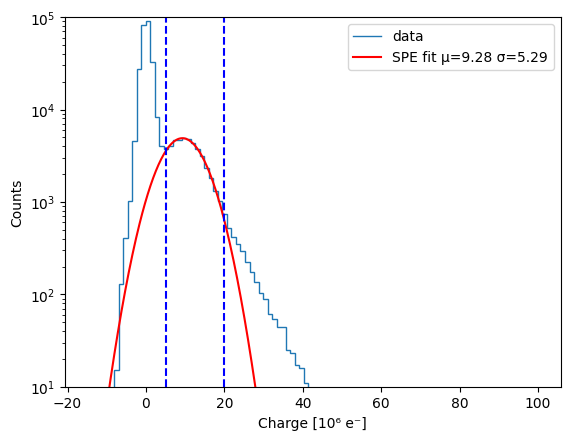

SPE 峰位: 8.48 ± 0.16
sigma  : 4.58 ± 0.16


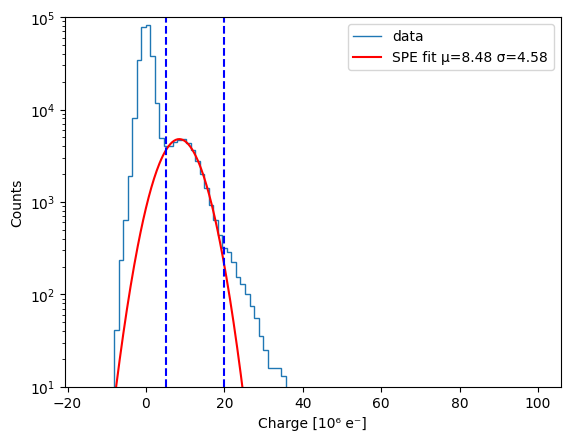

SPE 峰位: 9.19 ± 0.09
sigma  : 4.78 ± 0.10


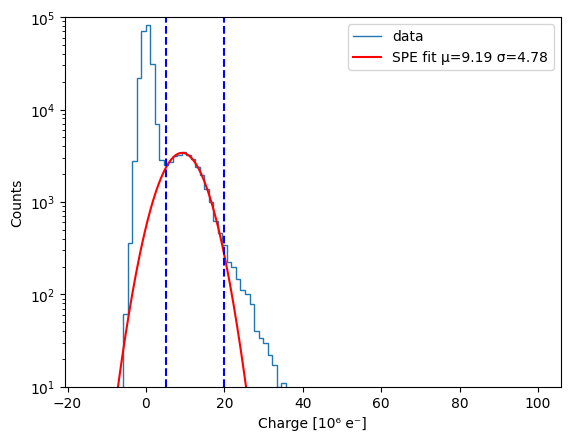

SPE 峰位: 9.37 ± 0.16
sigma  : 5.21 ± 0.19


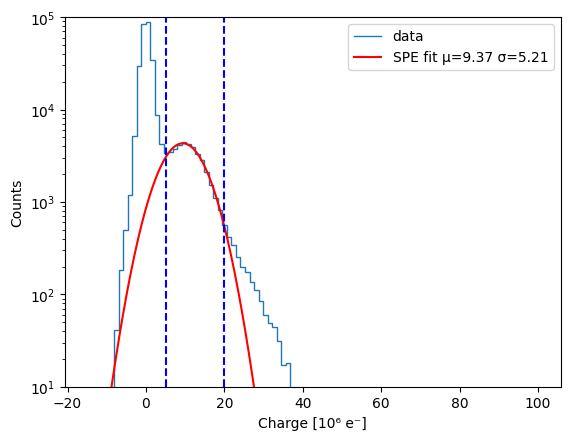

SPE 峰位: 9.25 ± 0.19
sigma  : 5.51 ± 0.22


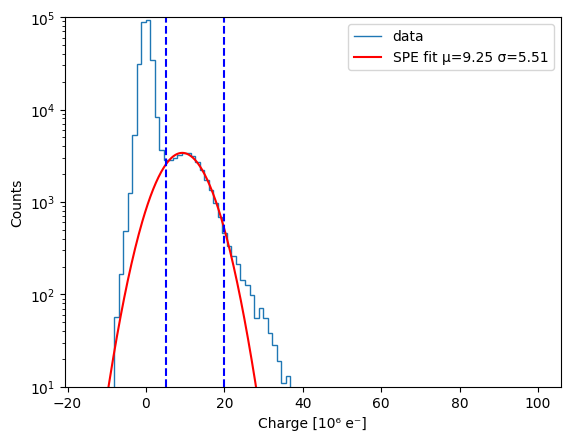

SPE 峰位: 9.39 ± 0.07
sigma  : 4.22 ± 0.08


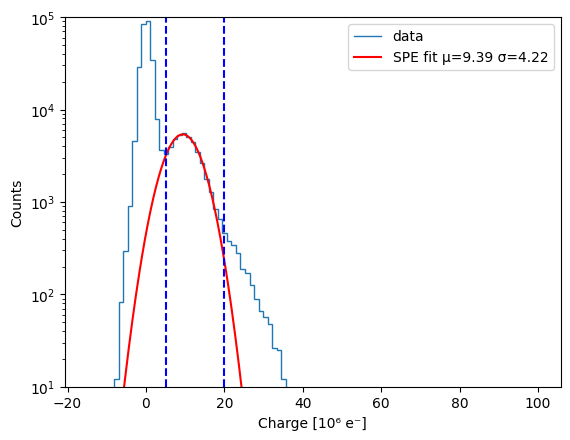

SPE 峰位: 9.27 ± 0.08
sigma  : 4.12 ± 0.09


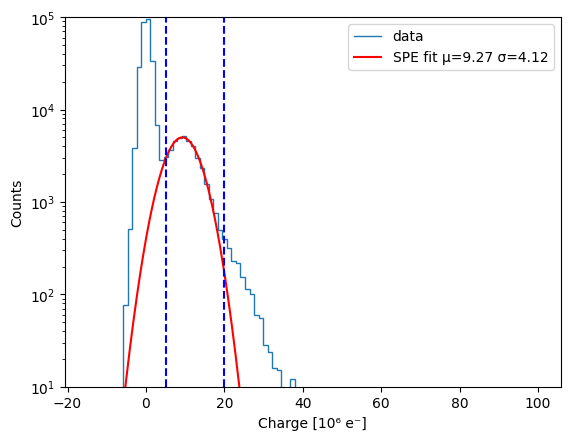

In [17]:

import matplotlib.pyplot as plt

fit_results = {}

for ch in channels:
    # if ch !=13 :
    #     continue
    data = np.array(integral_per_channel[ch])
    
    counts, edges = np.histogram(data, bins=100, range=(-15, 100))
    params, errors = fit_single_gaussian(
    counts, edges,
    mu_init=10.0,
    sigma_init=2.0,
    fit_range=(5, 20),
    mu_bounds=(0.1, 30),      # SPE 峰位范围
    sigma_bounds=(0, 12),    # sigma 不能太宽
    amp_bounds=(100, 1e5),   # 幅度合理范围
    )
    fit_results[(board, ch)] = {
        "board": board,
        "ch": ch,
        "SPE": round(float(params['mu']), 2),
        "sigma": round(float(params['sigma']), 2),  # 根据你实际的 params 索引调整
    }


    if params:
        print(f"SPE 峰位: {params['mu']:.2f} ± {errors['mu']:.2f}")
        print(f"sigma  : {params['sigma']:.2f} ± {errors['sigma']:.2f}")

        x_fit = np.linspace(-15, 100, 500)
        x = 0.5 * (edges[:-1] + edges[1:])

        plt.figure()
        plt.stairs(counts, edges, label="data")
        plt.plot(x_fit, gaussian(x_fit, params["amp"], params["mu"], params["sigma"]),
                 "r-", label=f"SPE fit μ={params['mu']:.2f} σ={params['sigma']:.2f}")
        plt.axvline(5, color='blue', linestyle='--', linewidth=1.5)
        plt.axvline(20, color='blue', linestyle='--', linewidth=1.5)
        plt.yscale("log")
        plt.xlabel("Charge [10⁶ e⁻]")
        plt.ylim(1e1,1e5)
        plt.ylabel("Counts")
        plt.legend()
        plt.show()


In [307]:
# from scipy.optimize import root_scalar

# try:
#     from scipy.misc import derivative
# except ImportError:
#     # 手动定义数值导数
#     def derivative(func, x0, dx=1e-6, args=(), order=3):
#         from scipy.optimize import approx_fprime
#         return approx_fprime([x0], func, dx, *args)[0]
    
# def find_extrema(f, x_min, x_max, num_points=1000, dx=1e-6):
#     """
#     在区间 [x_min, x_max] 内寻找函数 f(x) 的极大值和极小值点。

#     参数：
#     - f: 一元函数，f(x)
#     - x_min, x_max: 搜索区间
#     - num_points: 在区间内采样点数，越大精度越高
#     - dx: 计算数值导数的步长

#     返回：
#     - extrema_points: 列表，元素为 (x, f(x), 'max' 或 'min')
#     """

#     # 在区间内均匀采样
#     x_vals = np.linspace(x_min, x_max, num_points)
#     # 计算一阶导数
#     dy_vals = np.array([derivative(f, xi, dx=dx) for xi in x_vals])

#     extrema_points = []

#     for i in range(1, len(dy_vals)):
#         # 导数符号变化检测
#         if dy_vals[i-1] > 0 and dy_vals[i] < 0:
#             # 极大值附近，求导数零点
#             try:
#                 sol = root_scalar(lambda x: derivative(f, x, dx=dx), bracket=[x_vals[i-1], x_vals[i]], method='brentq')
#                 if sol.converged:
#                     x_ext = sol.root
#                     y_ext = f(x_ext)
#                     extrema_points.append((x_ext, y_ext, 'max'))
#             except ValueError:
#                 # 可能区间内无根，跳过
#                 pass

#         elif dy_vals[i-1] < 0 and dy_vals[i] > 0:
#             # 极小值附近，求导数零点
#             try:
#                 sol = root_scalar(lambda x: derivative(f, x, dx=dx), bracket=[x_vals[i-1], x_vals[i]], method='brentq')
#                 if sol.converged:
#                     x_ext = sol.root
#                     y_ext = f(x_ext)
#                     extrema_points.append((x_ext, y_ext, 'min'))
#             except ValueError:
#                 pass

#     return extrema_points

# def two_gauss(x, A0, mu0, sigma0, A1, mu1, sigma1):
#     """
#     三高斯叠加函数：
#     - Pedestal（噪声基底）: 高斯1 (A0, mu0, sigma0)
#     - 单光电子峰（SPE）: 高斯2 (A1, mu1, sigma1)
#     - 双光电子峰（DPE）: 高斯3 (A2, 2*mu1, sigma2)
#     """
#     gauss_pedestal = A0 * np.exp(-(x - mu0)**2 / (2 * sigma0**2))
#     gauss_spe = A1 * np.exp(-(x - mu1-mu0)**2 / (2 * ( sigma1**2 + sigma0**2 )) ) 
#     #gauss_dpe = A2 * np.exp(-(x - 2*mu1 - mu0 )**2 / (2 *(2*sigma1**2 + sigma0**2)))
#     # gauss_tpe = A3 * np.exp(-(x - 3*mu1 - mu0 )**2 / (2 *(3*sigma1**2 + sigma0**2)))        
#     return gauss_pedestal + gauss_spe 


# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# def two_gauss_fit(df, p0, bounds):
#     """
#     对 DataFrame 中的 'Area' 列进行双高斯拟合

#     参数:
#         df: pandas DataFrame，必须包含 'Area' 列
#         p0: list or tuple, 初始参数 [A1, mu1, sigma1, A2, mu2, sigma2]
#         bounds: tuple, 参数边界 (lower_bounds, upper_bounds)

#     返回:
#         params: 拟合参数数组
#         params_covariance: 协方差矩阵
#         X: 直方图的 bin 中心点
#         Y: 直方图计数值
#     """
#     # 绘制直方图并获取数据
#     count, bins, *_ = plt.hist(
#         df['Area'].values,
#         bins=np.linspace(-10, 30, 100),
#         histtype='step',
#         lw=1,
#         label='Area'
#     )
#     X = (bins[1:] + bins[:-1]) / 2
#     Y = count

#     # 执行双高斯拟合
#     params, params_covariance = curve_fit(two_gauss, X, Y, p0=p0, bounds=bounds)
#     param_errors = np.sqrt(np.diag(params_covariance))

#     # 打印拟合参数
#     print("Fitted parameters (Two Gaussians):")
#     print(f"Gauss 1: A1={params[0]:.2f}, mu1={params[1]:.2f} ± {param_errors[1]:.3f}, sigma1={params[2]:.2f} ± {param_errors[2]:.3f}")
#     print(f"Gauss 2: A2={params[3]:.2f}, mu2={params[4]:.2f} ± {param_errors[4]:.3f}, sigma2={params[5]:.2f} ± {param_errors[5]:.3f}")

#     return params, params_covariance, X, Y
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_two_gauss_fit(df, params, params_covariance, X, Y, ftag, fstring, save_path=False):
#     """
#     绘制双高斯拟合结果（Pedestal + SPE）
    
#     参数：
#         df: DataFrame，包含 'Area' 和 'Ch' 列
#         params: 拟合参数 [A0, mu0, sigma0, A1, mu1, sigma1]
#         params_covariance: 协方差矩阵
#         X, Y: 直方图 bin 中心和计数值
#         ftag, fstring: 用于文件名标识
#         save_path: 若为 True 则保存图片，默认 False
#     """
#     # 提取参数
#     A0, mu0, sigma0, A1, mu1, sigma1 = params[:6]
    
#     # 计算 SPE 峰的实际位置和宽度
#     mu_spe = mu0 + mu1
#     sigma_spe = np.sqrt(sigma0**2 + sigma1**2)
    
#     # 定义双高斯模型（用于总拟合曲线）
#     def two_gauss_model(x, A0, mu0, sigma0, A1, mu1, sigma1):
#         g1 = A0 * np.exp(-((x - mu0) / sigma0)**2 / 2)
#         g2 = A1 * np.exp(-((x - (mu0 + mu1)) / np.sqrt(sigma0**2 + sigma1**2))**2 / 2)
#         return g1 + g2
    
#     # 计算残差和 R²
#     residuals = Y - two_gauss_model(X, *params)
#     ss_res = np.sum(residuals**2)
#     ss_tot = np.sum((Y - np.mean(Y))**2)
#     r_squared = 1 - (ss_res / ss_tot)
    
#     # 计算 SPE 相对分辨率及其误差
#     perr = np.sqrt(np.diag(params_covariance))
#     res = sigma_spe / mu_spe
#     # 误差传递（忽略 mu_spe 误差中的 mu0 贡献，简化为仅 sigma_spe 和 mu1 的误差）
#     res_err = res * np.sqrt((perr[5] / sigma1)**2 + (perr[4] / mu1)**2)  # perr[4]=sigma1的误差, perr[5]=mu1的误差
    
#     # 寻找极值点（用于峰谷比）
#     def f(x):
#         return two_gauss_model(x, *params)
#     # 需要 find_extrema 函数（假设已定义），若未定义可自行实现简单版本
#     try:
#         extrema_points = find_extrema(f, 0, 20, num_points=1000, dx=1e-6)
#         max_y_values = [y for x, y, t in extrema_points if t == 'max']
#         min_y_values = [y for x, y, t in extrema_points if t == 'min']
#         peak_valley_ratio = max_y_values[0] / min_y_values[0] if min_y_values else np.nan
#     except NameError:
#         # 如果 find_extrema 不存在，计算两个峰和谷的简单近似
#         x_vals = np.linspace(0, 20, 2000)
#         y_vals = f(x_vals)
#         from scipy.signal import argrelextrema
#         max_idx = argrelextrema(y_vals, np.greater)[0]
#         min_idx = argrelextrema(y_vals, np.less)[0]
#         if len(max_idx) >= 1 and len(min_idx) >= 1:
#             peak_valley_ratio = y_vals[max_idx[0]] / y_vals[min_idx[0]]
#         else:
#             peak_valley_ratio = np.nan
#         print("使用 scipy.signal 代替 find_extrema")
    
#     # 构建文本框内容
#     textstr = '\n'.join([
#         fr'$\mu_{{0}}$:   {mu0:.2f}±{perr[1]:.2f}',
#         fr'$\sigma_{{0}}$:   {sigma0:.2f}±{perr[2]:.2f}',
#         fr'$\mu_{{SPE}}$:   {mu_spe:.2f}±{np.sqrt(perr[1]**2 + perr[4]**2):.2f}',
#         fr'$\sigma_{{SPE}}$:   {sigma_spe:.2f}±{np.sqrt(perr[2]**2 + perr[5]**2):.2f}',
#         fr'Res:    {res:.3f}±{res_err:.3f}',
#         fr'Peak-Valley Ratio: {peak_valley_ratio:.2f}'
#     ])
    
#     # 绘图设置
#     plt.figure(figsize=(8, 6))
#     plt.hist(df['Area'], bins=100, range=(-10, 30), histtype='step', color='black', alpha=0.8, label='Data')
    
#     # 总拟合曲线
#     X_plot = np.linspace(-10, 30, 500)
#     plt.plot(X_plot, two_gauss_model(X_plot, *params), 'r-', label='Total fit')
    
#     # 两个高斯分量
#     plt.plot(X_plot, A0 * np.exp(-((X_plot - mu0) / sigma0)**2 / 2), 'b--', label='Pedestal')
#     plt.plot(X_plot, A1 * np.exp(-((X_plot - mu_spe) / sigma_spe)**2 / 2), 'g--', label='SPE')
    
#     plt.ylim(1.E0, 1.E6)
#     plt.xlabel("Charge [$10^{6} e^{-}$]", labelpad=20, fontsize=20)
#     plt.ylabel("Counts", labelpad=20, fontsize=20)
#     plt.xticks([-10, 0, 10, 20, 30, 40, 50, 60], 
#                ['-10','0','10', '20', '30', '40', '50', '60'], fontsize=20)
#     plt.yticks(fontsize=20)
#     plt.tick_params(which='both', direction='in', labelsize=20, pad=7, length=6, width=1.5)
    
#     for spine in plt.gca().spines.values():
#         spine.set_linewidth(1.5)
    
#     plt.text(0.6, 0.98, textstr, transform=plt.gca().transAxes,
#              fontsize=14, ha='left', va='top',
#              bbox=dict(facecolor='none', edgecolor='none'))
#     plt.yscale('log')
    
#     if save_path:
#         ch_val = df['Ch'].values[0] if 'Ch' in df.columns else 0
#         plt.savefig(f'figs/{ftag}_SPE_{fstring}_{ch_val}.pdf', dpi=300, bbox_inches='tight')
#     plt.show()

In [ ]:
# initial_guess = [8.E4, 0, 2, 1.E2, 15, 5]
# bounds = (
#     [1.E3, -2, 0, 1.E1, 5, 0],          # 下限（幅值、sigma需≥0）
#     [1.E6, 2, 5, 5.E3, 20, 10]  # 上限
# )

# for ch in channels:
#     if ch !=15 :
#         continue
#     vals = np.array(integral_per_channel[ch])   # 已经是 PE 单位
#     print(f"\n================== 拟合 Board {board}, Channel {ch}，数据点数：{len(vals)} =====")
    
#     df_fit = pd.DataFrame({'Area': vals})
#     try:
#         params, cov, X, Y = two_gauss_fit(
#             df_fit, initial_guess, bounds
#         )
#         plot_two_gauss_fit(
#             df_fit, params, cov, X, Y,
#             ftag=f'Board{board}_Ch{ch}',
#             fstring='IntegralArea_PE',
#             save_path=False
#         )
#     except Exception as e:
#         print(f" ** failed to fit:{e}")

In [ ]:
# import sys
# import os

# # 获取当前工作目录（Jupyter 当前所在目录）
# current_dir = os.getcwd()
# # 构建上级目录下的 ProcessLocalData 路径
# fit_package_dir = os.path.abspath(os.path.join(current_dir, '../ProcessLocalData'))
# if fit_package_dir not in sys.path:
#     sys.path.append(fit_package_dir)

# # 现在可以导入 fit_package（文件名不含 .py）
# import fit_package as fp


# #########################################
# # 适用于 PE 能谱的典型初值（参考原代码）
# # initial_guess = [8.E4, 0, 2, 1.E2, 5, 5, ]
# # bounds = (
# #     [1.E3, -2, 0, 1.E1, 0, 0,  1E1],          # 下限（幅值、sigma需≥0）
# #     [1.E6, 2, 5, 5.E5, 20, 10, 1E3]  # 上限
# # )
# ###############################
# # initial_guess = [1.E5, 0, 2, 1.E4, 14, 3, 1.E3, 1E1]
# # bounds = (
# #     [1.E3, -2, 0, 1.E2, 0, 1, 1.E1, 1E1],           # 下限（幅值、sigma需≥0）
# #     [1.E6, 2, 5, 5.E5, 20, 10, 1.E4, 1E3]  # 上限
# # )
# # ############# LED 1.48V ， 30ns#############
# initial_guess = [7.E4, 0, 2, 1.E3, 20, 5, 1.E2, 10E0]
# bounds = (
#     [1.E3, -2, 0, 1.E2, 10, 1, 1.E1, 1E0],          # 下限（幅值、sigma需≥0）
#     [1.E6, 2, 5, 5.E4, 60, 8, 1.E3, 1E2]  # 上限
# )
# ####################################


# # 循环里拟合完之后

# for ch in channels:
#     if ch !=13 :
#         continue
#     vals = np.array(integral_per_channel[ch])   # 已经是 PE 单位
#     print(f"\n================== 拟合 Board {board}, Channel {ch}，数据点数：{len(vals)} =====")
    
#     df_fit = pd.DataFrame({'Area': vals})
#     try:
#         params, cov, X, Y = fp.three_gauss_fit(
#             df_fit, initial_guess, bounds, 
#             case=False   # 使用 four_gauss 模型（三个高斯峰+基座？）
#         )
#         fp.plot_three_gauss_fit(
#             df_fit, params, cov, X, Y,
#             ftag=f'board{board}_ch{ch}',
#             fstring='Area_PE',
#             save_path=False,
#             case=False
#         )
#     except Exception as e:
#         print(f" ** failed to fit:{e}")
   
#     print(f"\n--------Board {board}_Ch {ch}--SPE:{float(params[4]):.2f}---Sigma:{float(params[5]):.2f}---\n")

In [20]:
# fit_results[(0, 13)] 

{'board': 0, 'ch': 13, 'SPE': 9.25, 'sigma': 5.51}

In [21]:
# ######## 打印所有拟合结果
# spe_gain =[]
# for (board, ch), val in fit_results.items():
#     print(f"Board {board} Ch {ch}: SPE={val['SPE']}, sigma={val['sigma']}")
#     spe_gain.append(val['SPE'])


Board 0 Ch 9: SPE=9.28, sigma=5.29
Board 0 Ch 10: SPE=8.48, sigma=4.58
Board 0 Ch 11: SPE=9.19, sigma=4.78
Board 0 Ch 12: SPE=9.37, sigma=5.21
Board 0 Ch 13: SPE=9.25, sigma=5.51
Board 0 Ch 14: SPE=9.39, sigma=4.22
Board 0 Ch 15: SPE=9.27, sigma=4.12


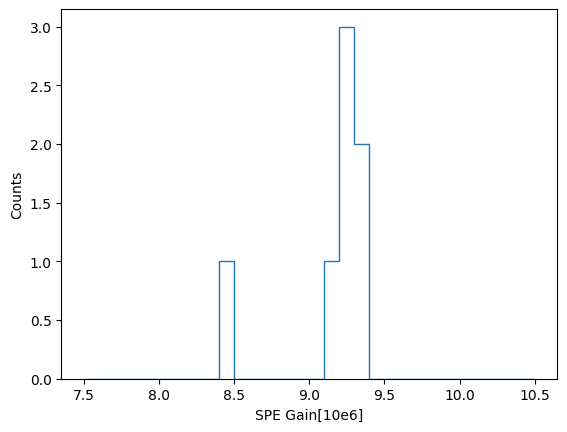

In [22]:
# plt.hist(spe_gain,range=(7.5, 10.5),  bins=30, histtype='step' )
# plt.xlabel('SPE Gain[10e6]')
# plt.ylabel('Counts')
# plt.show()


In [24]:
# ######## 打印所有拟合结果
# spe_gain =[]
# for (board, ch), val in fit_results.items():
#     print(f"Board {board} Ch {ch}: SPE={val['SPE']}, sigma={val['sigma']}")
#     spe_gain.append(val['SPE'])
# np.mean(spe_gain)

Board 0 Ch 9: SPE=9.28, sigma=5.29
Board 0 Ch 10: SPE=8.48, sigma=4.58
Board 0 Ch 11: SPE=9.19, sigma=4.78
Board 0 Ch 12: SPE=9.37, sigma=5.21
Board 0 Ch 13: SPE=9.25, sigma=5.51
Board 0 Ch 14: SPE=9.39, sigma=4.22
Board 0 Ch 15: SPE=9.27, sigma=4.12


np.float64(9.175714285714283)

### 数据写入数据库

In [1]:
# import sqlite3
# conn = sqlite3.connect("/home/yjj/pmtdatabase/pmt-data-client/data/pmt_data.db")
# conn.execute("SELECT 1").fetchone()
# conn.close()

In [2]:
# # 导入模块（需确保 pmt_database.py 在 Python 路径中）
# import pmt_database as pmt_db
# import os
# # os.makedirs("data", exist_ok=True)
# # mapping_path = '/home/daq/DAQ_DEMO/mapping.json'
# mapping_path = '/mnt/data/TPC/run5_Ar/mapping.json'
# # rawdata_path = f'/mnt/data/TPC/run6_Xe/{run_id}/'
# # runinfo_path = rawdata_path+'runinfo.json'

# # 一行创建 recorder
# # rec = pmt_db.create_recorder(mapping_path, "/home/yjj/pmtdatabase/pmt-data-client/data/pmt_data.db")
# # 加载 runinfo
# # pmt_db.load_runinfo_to_recorder(rec, runinfo_path)
# ##-----------singlechannel------------
# # rec.record(0, 15, {"gain": 9.27 , "hv":783.08}) ### pmt1
# # rec.record(0, 14, {"gain": 9.39, "hv":790.58}) ### pmt2
# # rec.record(0, 13, {"gain": 9.25, "hv":784.40}) ### pmt3
# # rec.record(0, 12, {"gain": 9.37, "hv":797.54}) ### pmt4
# # rec.record(0, 11, {"gain": 9.19, "hv":790.48}) ### pmt5
# # rec.record(0, 10, {"gain": 9.18, "hv":798.35}) ### pmt6
# # rec.record(0, 9, {"gain": 9.28, "hv":797.53}) ### pmt7

# ###----------multichannel-----
# # rec.default_run_info["hv"] = 800.0
# # for (board, ch), val in fit_results.items():
#     # rec.record(board, ch, {"gain": val['SPE']})
    
# #####-----LAr----
# # rec.record(0, 12, {"run_type":"run5_Ar", "measurement_time":"2026-05-15 13:51:00","gain":8.99, "hv":800,"temperature":87.,"notes":"Ar temperature calibration"})
# # rec.record(0, 13, {"run_type":"run5_Ar", "measurement_time":"2026-05-15 13:51:00","gain":9.60, "hv":800,"temperature":87.,"notes":"Ar temperature calibration"})
# # rec.record(0, 14, {"run_type":"run5_Ar", "measurement_time":"2026-05-15 13:51:00","gain":8.87, "hv":800,"temperature":87.,"notes":"Ar temperature calibration"})
# # rec.record(0, 15, {"run_type":"run5_Ar", "measurement_time":"2026-05-15 13:51:00","gain":10.74, "hv":800,"temperature":87.,"notes":"Ar temperature calibration"})
# # rec.record(0, 11, {"run_type":"run5_Ar", "measurement_time":"2026-05-15 13:51:00","gain":9.28, "hv":800,"temperature":87.,"notes":"Ar temperature calibration"})
# # rec.record(0, 10, {"run_type":"run5_Ar", "measurement_time":"2026-05-15 13:51:00","gain":8.57, "hv":800,"temperature":87.,"notes":"Ar temperature calibration"})
# # rec.record(0, 9, { "run_type":"run5_Ar", "measurement_time":"2026-05-15 13:51:00","gain":7.07, "hv":800,"temperature":87.,"notes":"Ar temperature calibration"})
# ####


In [34]:
# import sqlite3
# from datetime import datetime
# import pmt_database as pmt_db
# mapping_path = '/mnt/data/TPC/run5_Ar/mapping.json'
# # rec = pmt_db.create_recorder(mapping_path, "/home/yjj/pmtdatabase/pmt-data-client/data/pmt_data.db")

# # 获取连接（假设 rec 是 PMTDataRecorder 实例）
# conn = sqlite3.connect(rec.db_path, timeout=10)
# conn.execute("PRAGMA journal_mode=WAL")
# cursor = conn.cursor()

# # 插入一行，指定 id=100（请确保该 id 尚未被占用）
# cursor.execute("""
#     INSERT INTO measurements (
#         pmt_id, board_id, channel_id, measurement_time,
#         run_type, hv, temperature, gain, dark_count_rate, notes
#     ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?,?)
# """, ( 
#     "LV2204",                # pmt_id
#     0,                       # board_id
#     0,                      # channel_id
#     "2025-08-03 14:30:00",   # measurement_time
#     "Room_Temp",           # run_type
#     750,                   # hv
#     298.15,                    # temperature
#     5.417,                    # gain
#     159.24,    
#     "add room temp test results"
# ))
# conn.commit()
# conn.close()

In [9]:
rec.db_path

'/home/yjj/pmtdatabase/pmt-data-client/data/pmt_data.db'

### 删除特定行

In [20]:
# import sqlite3

# db_path = "/home/yjj/pmtdatabase/pmt-data-client/data/pmt_data.db"
# # id_to_delete = 87   # 要删除的记录ID

# with sqlite3.connect(db_path) as conn:
#     cursor = conn.execute("DELETE FROM measurements WHERE id = ?", (id_to_delete,))
#     conn.commit()
#     print(f"删除了 {cursor.rowcount} 行")

删除了 1 行


In [280]:
# for board in [0,1]:
#     records_board=records[records["board"]==board]
#     print(f"Unique channels for board {board}: {np.unique(records_board['channel'])}")

Unique channels for board 0: [ 9 10 11 12 13 14 15]
Unique channels for board 1: []
